### 📊 AED para explorar o IPS (Indicador Psicossocial)

**Base:** `df_base_2.parquet` — atualização gerada no Notebook `03_AED_IEG.ipynb`.

**❓Pergunta chave:**
- Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

**Sub-perguntas:**
- Qual a distribuição do IPS por ano?
- IPS baixo em um ano está associado a queda de IDA ou IEG no ano seguinte?
- Existe um limiar de IPS abaixo do qual o risco de queda aumenta?

### ⚙️ Import e Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_parquet('../../data/db/01_silver_processed/df_base_2.parquet')

print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')

df_base: 3030 linhas | 31 colunas


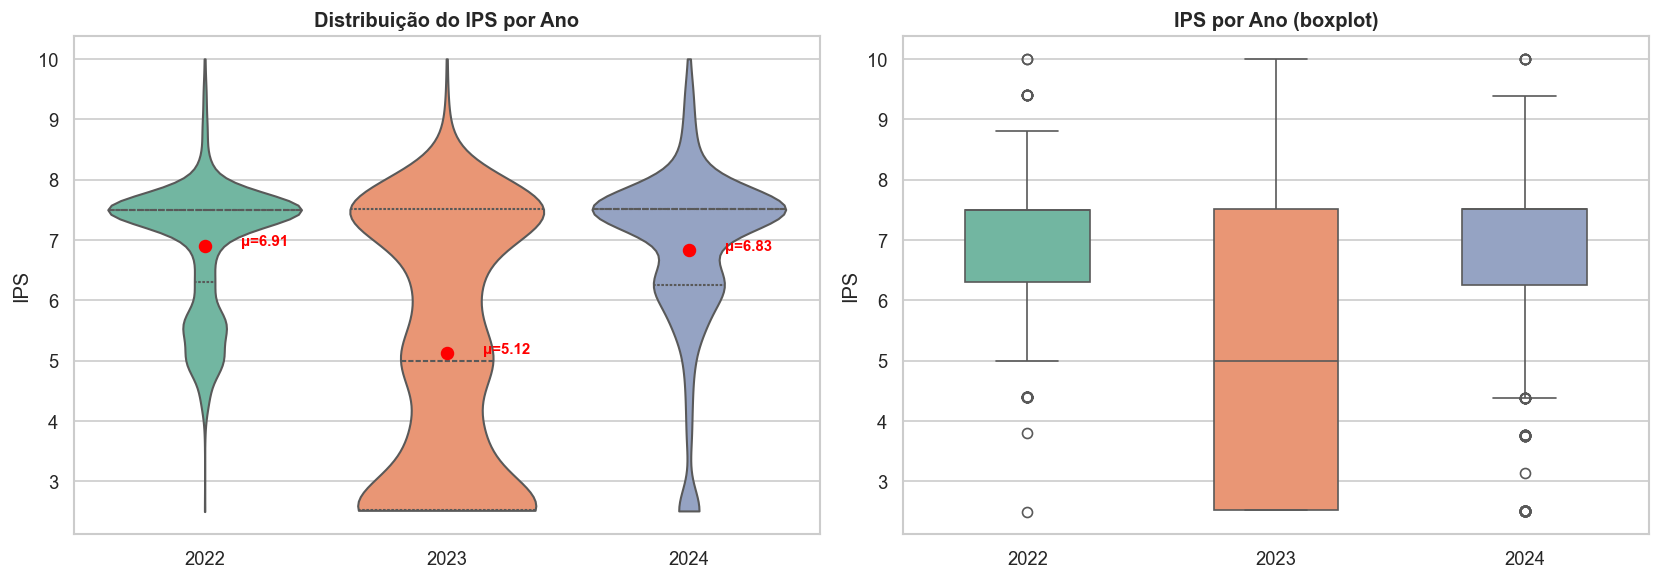

=== IPS — Estatísticas por ano ===
       count  mean   std   min   25%   50%   75%   max
ano                                                   
2022   860.0  6.90  1.07  2.50  6.30  7.50  7.50  10.0
2023   945.0  5.12  2.09  2.52  2.52  5.00  7.52  10.0
2024  1054.0  6.83  1.43  2.51  6.26  7.51  7.51  10.0


In [2]:
# Distribuição do IPS por ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_violin = df[df['IPS'].notna()].copy()
dados_violin['ano'] = dados_violin['ano'].astype(str)

sns.violinplot(data=dados_violin, x='ano', y='IPS', ax=axes[0],
               palette='Set2', inner='quartile', cut=0)

medias = dados_violin.groupby('ano')['IPS'].mean()
for i, (ano, media) in enumerate(medias.items()):
    axes[0].scatter(i, media, color='red', s=50, zorder=5)
    axes[0].text(i + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')

axes[0].set_title('Distribuição do IPS por Ano', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IPS')

sns.boxplot(data=dados_violin, x='ano', y='IPS', ax=axes[1], palette='Set2', width=0.5)
axes[1].set_title('IPS por Ano (boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IPS')

plt.tight_layout()
plt.show()

print('=== IPS — Estatísticas por ano ===')
print(df.groupby('ano')['IPS'].describe().round(2).to_string())

##### 💡 Insights

- IPS estável entre 2022 (média = 6.91) e 2024 (6.83), com mediana em 7.5
- **2023 é novamente diferente:** média caiu para 5.12, desvio dobrou
  - Mesmo padrão já observado no IAA 

- O que será que aconteceu em 2023? 
  - Revisando o arquivo `data/documentation/resumo_relatorios_2018_a_2014.md`, em 2023 houve uma grande expansão de 60 para 81 turmas
  - É possível que mais pessoas tenham sido contratadas e com isso a metodologia de avaliação tenha mudado?
  - Como será que o IPS muda por turma?

### IPS por Turma em 2023

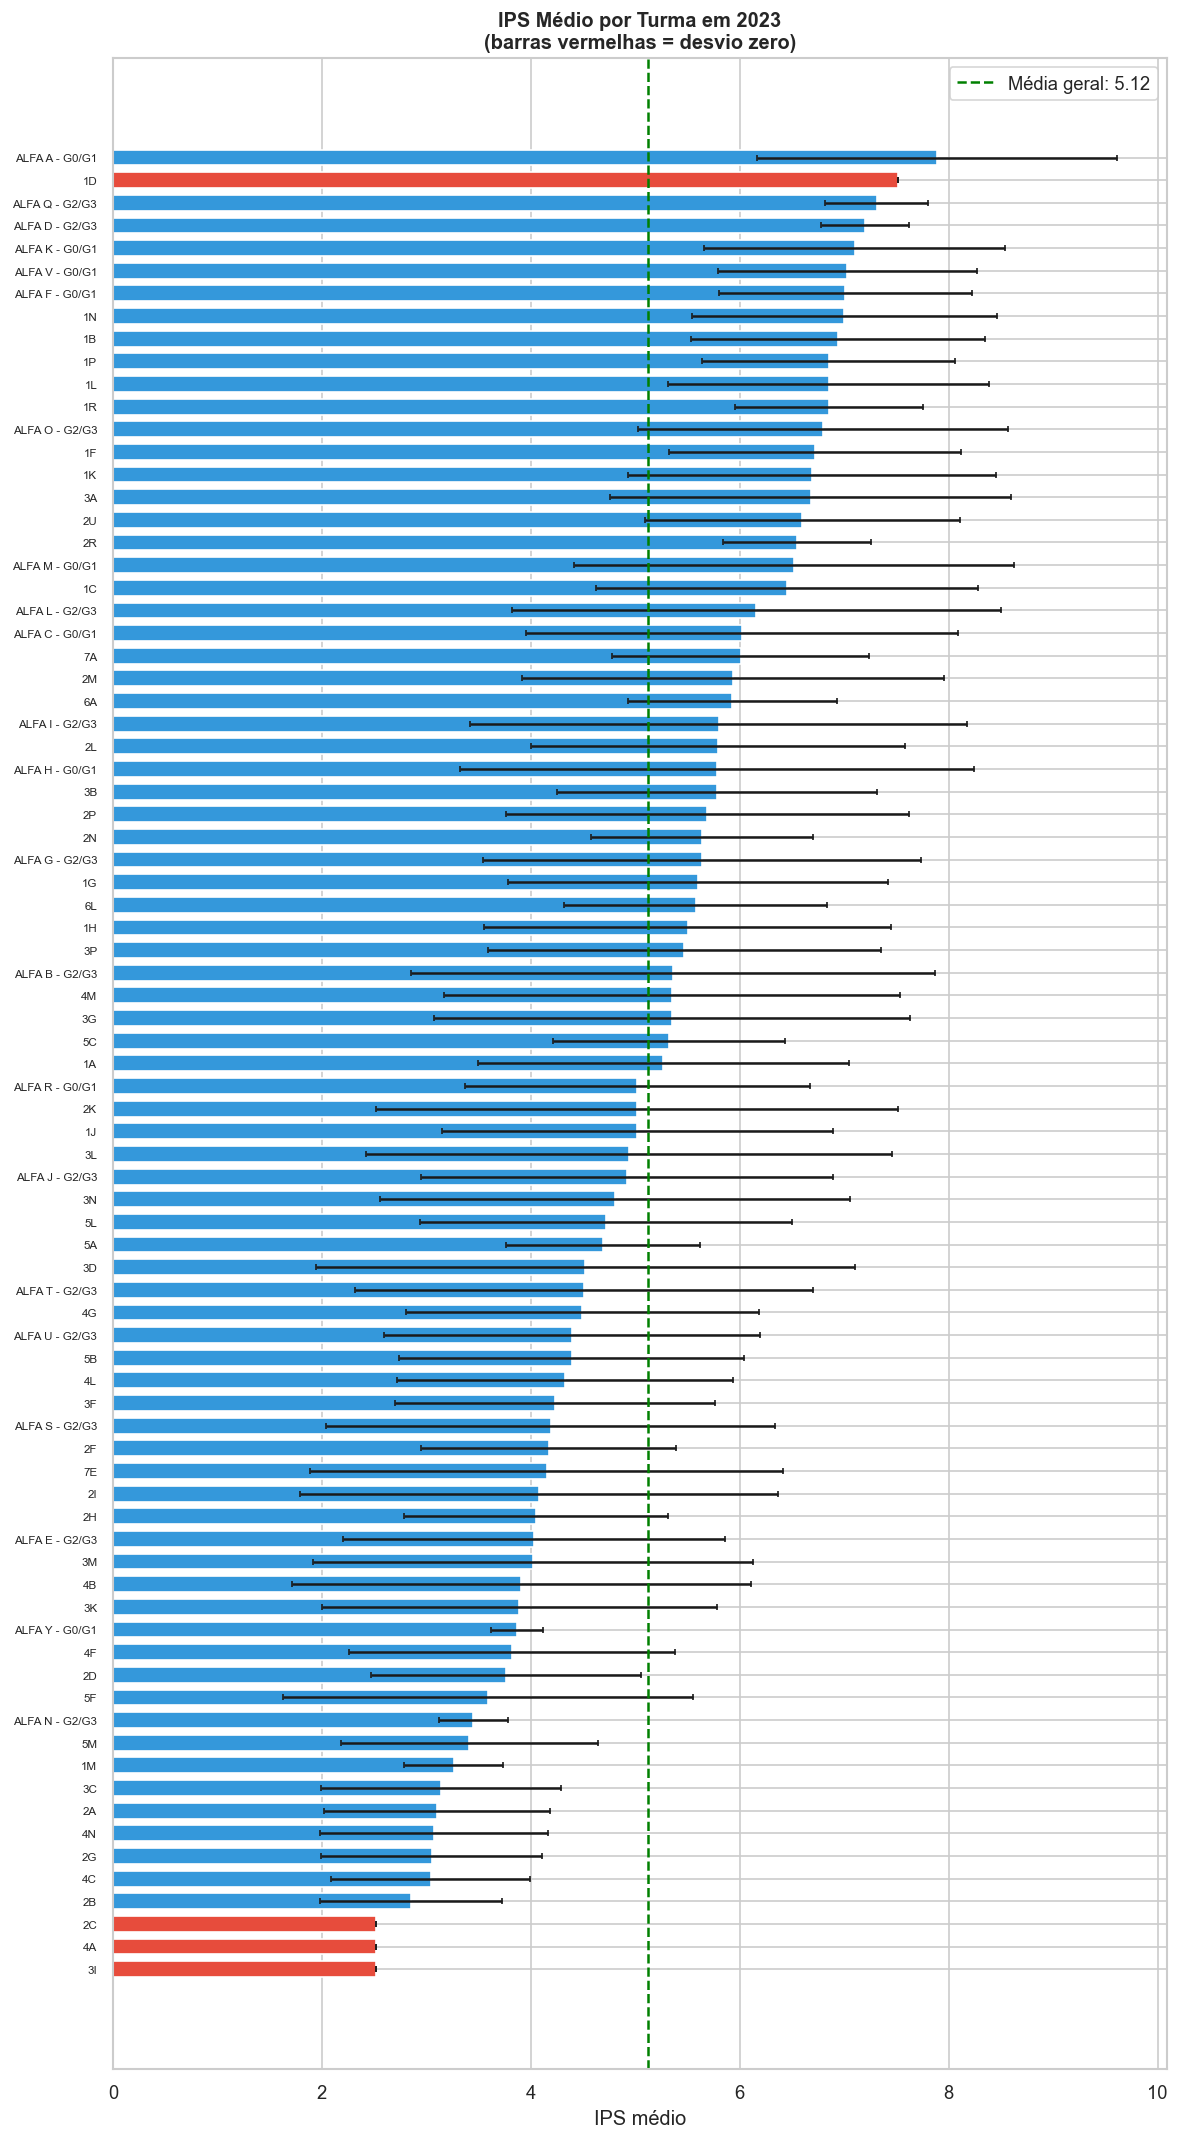

Turmas com desvio zero (todos receberam mesma nota): 4
Alunos afetados: 41
Amplitude entre turmas: 5.37


In [3]:
# Visualização do IPS por turma em 2023
df_2023 = df[(df['ano'] == 2023) & df['IPS'].notna()].copy()

turma_stats = df_2023.groupby('turma')['IPS'].agg(['mean', 'std', 'count']).round(2)
turma_stats.columns = ['media', 'desvio', 'n']
turma_stats = turma_stats.sort_values('media')

# Classificar turmas: desvio zero = vermelho, resto = azul
cores = []
for _, row in turma_stats.iterrows():
    if row['desvio'] == 0:
        cores.append('#e74c3c')
    else:
        cores.append('#3498db')

fig, ax = plt.subplots(figsize=(10, 18))

ax.barh(range(len(turma_stats)), turma_stats['media'], 
        xerr=turma_stats['desvio'], color=cores, 
        edgecolor='white', height=0.7, capsize=2)
ax.set_yticks(range(len(turma_stats)))
ax.set_yticklabels(turma_stats.index, fontsize=7)
ax.set_xlabel('IPS médio')
ax.set_title('IPS Médio por Turma em 2023\n(barras vermelhas = desvio zero)', fontweight='bold')
ax.axvline(df_2023['IPS'].mean(), color='green', linestyle='--', linewidth=1.5, 
           label=f'Média geral: {df_2023["IPS"].mean():.2f}')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Resumo
std_zero = turma_stats[turma_stats['desvio'] == 0]
print(f'Turmas com desvio zero (todos receberam mesma nota): {len(std_zero)}')
print(f'Alunos afetados: {int(std_zero["n"].sum())}')
print(f'Amplitude entre turmas: {turma_stats["media"].max() - turma_stats["media"].min():.2f}')

In [4]:
print(turma_stats.to_string())

print(f'\n=== Amplitude entre turmas ===')
print(f'  Maior média: {turma_stats["media"].max():.2f}')
print(f'  Menor média: {turma_stats["media"].min():.2f}')
print(f'  Diferença: {turma_stats["media"].max() - turma_stats["media"].min():.2f}')

                media  desvio   n
turma                            
3I               2.52    0.00   6
4A               2.52    0.00  15
2C               2.52    0.00  15
2B               2.85    0.87  15
4C               3.04    0.95  12
2G               3.05    1.06  14
4N               3.07    1.09   9
2A               3.10    1.08  17
3C               3.14    1.15   8
1M               3.26    0.47  11
5M               3.41    1.23  14
ALFA N - G2/G3   3.45    0.33  10
5F               3.59    1.96   7
2D               3.76    1.29  14
4F               3.82    1.56  11
ALFA Y - G0/G1   3.87    0.25   6
3K               3.89    1.89  15
4B               3.91    2.20   9
3M               4.02    2.11  10
ALFA E - G2/G3   4.03    1.83  12
2H               4.05    1.26  13
2I               4.08    2.29   8
7E               4.15    2.26  13
2F               4.17    1.22  12
ALFA S - G2/G3   4.19    2.15  12
3F               4.23    1.53  12
4L               4.33    1.61  11
5B            

Turmas com dados em 2023 e 2024: 77

Turmas que subiram: 68 (88.3%)
Turmas que caíram: 9 (11.7%)
Turmas estáveis: 0
Delta médio: 1.62


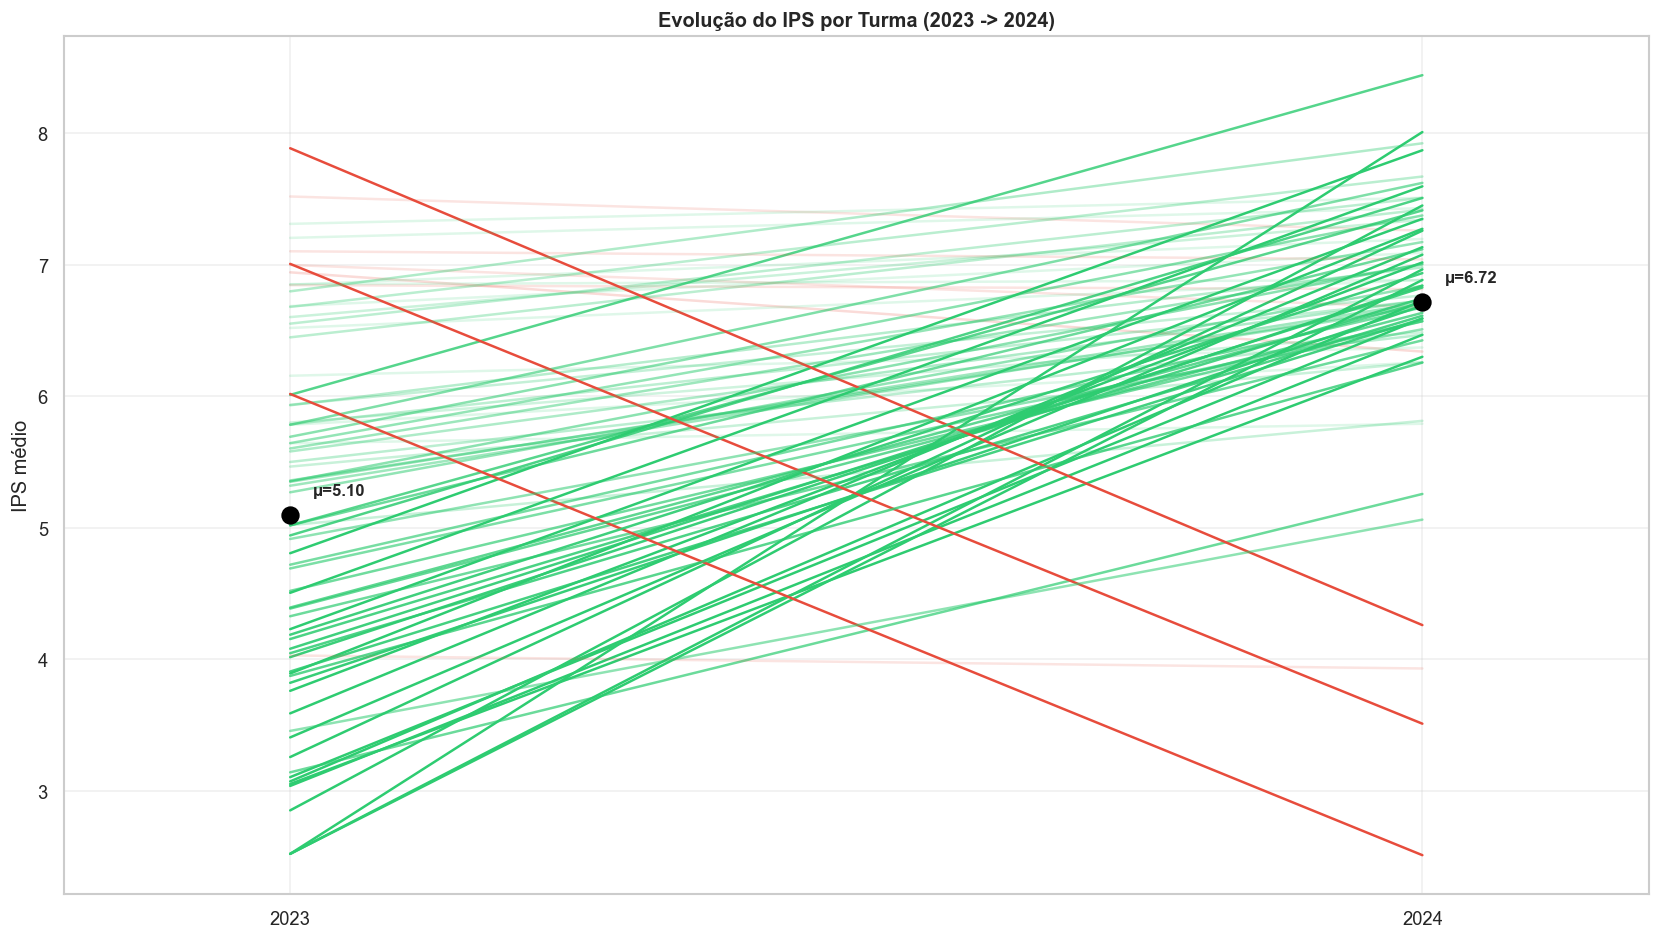

In [5]:
# IPS médio por turma: evolução 2023 → 2024
df_ips = df[(df['IPS'].notna()) & (df['ano'].isin([2023, 2024]))].copy()

# Média por turma e ano
pivot = df_ips.pivot_table(index='turma', columns='ano', values='IPS', aggfunc='mean')

# Manter apenas turmas presentes nos dois anos
pivot = pivot.dropna()
print(f'Turmas com dados em 2023 e 2024: {len(pivot)}')

# Calcular delta para colorir
pivot['delta'] = pivot[2024] - pivot[2023]

fig, ax = plt.subplots(figsize=(14, 8))

# Uma linha por turma, cor baseada na direção da mudança
for turma, row in pivot.iterrows():
    cor = '#2ecc71' if row['delta'] > 0 else '#e74c3c'
    alpha = min(abs(row['delta']) / 3, 1)  # mais opaco = mudança maior
    alpha = max(alpha, 0.15)
    ax.plot([2023, 2024], [row[2023], row[2024]], 
            color=cor, alpha=alpha, linewidth=1.5)

# Médias gerais
for ano in [2023, 2024]:
    media = pivot[ano].mean()
    ax.scatter(ano, media, color='black', s=100, zorder=5)
    ax.text(ano + 0.02, media + 0.15, f'μ={media:.2f}', fontsize=10, fontweight='bold')

ax.set_xticks([2023, 2024])
ax.set_xlabel('')
ax.set_ylabel('IPS médio')
ax.set_title('Evolução do IPS por Turma (2023 -> 2024)', fontweight='bold')
ax.set_xlim(2022.8, 2024.2)
ax.grid(True, alpha=0.3)

# Resumo
subiu = (pivot['delta'] > 0).sum()
caiu = (pivot['delta'] < 0).sum()
estavel = (pivot['delta'] == 0).sum()
print(f'\nTurmas que subiram: {subiu} ({subiu/len(pivot)*100:.1f}%)')
print(f'Turmas que caíram: {caiu} ({caiu/len(pivot)*100:.1f}%)')
print(f'Turmas estáveis: {estavel}')
print(f'Delta médio: {pivot["delta"].mean():.2f}')

plt.tight_layout()
plt.show()

##### 💡 Insights

**Grande variação entre turmas em 2023:**
- Diferença de 5.37 pontos entre turmas (de 2.52 a 7.89) numa escala de ~2.5 a 10
- 4 turmas com desvio zero (ou seja, todos os alunos receberam a mesma nota!)
  - sugere avaliação não individualizada
  - ou preencheram valores nulos da base de dados de 2023 com o piso
- ~30 turmas abaixo da média (2.5–4.5) e ~20 acima (5.5–7.9), poucas no centro
- A nota de IPS parece ser mais influenciada pela turma/avaliador do que pelo aluno individual

**Evolução 2023 → 2024 confirma o padrão:**
- Das 77 turmas presentes nos dois anos, **88.3% subiram** 
- Subida tão generalizada não é parece ser uma melhora real. Pode ser que algo mudou na escala de avaliação

**🤖 Ideias de como abordar esses dados discrepantes de 2023 no ML**
- Normalizar IPS dentro da turma (z-score) para tentar remover o efeito do avaliador
- Normalizar por percentil dentro do ano — mais simples
- Feature binária `ips_no_piso` para sinalizar alunos com valor mínimo

### IPS de um ano prediz queda no ano seguinte

In [6]:
# Análise temporal: IPS em um ano prediz queda de IDA ou IEG no ano seguinte?
# Precisamos de alunos com dados em anos consecutivos

df_temp = df[df['IPS'].notna() & df['IDA'].notna() & df['IEG'].notna()].copy()

# Criar pares ano-a-ano por aluno
pares = []
for ra, grupo in df_temp.groupby('RA'):
    grupo = grupo.sort_values('ano')
    for i in range(len(grupo) - 1):
        atual = grupo.iloc[i]
        proximo = grupo.iloc[i + 1]
        pares.append({
            'RA': ra,
            'ano_atual': atual['ano'],
            'ano_proximo': proximo['ano'],
            'IPS_atual': atual['IPS'],
            'IDA_atual': atual['IDA'],
            'IDA_proximo': proximo['IDA'],
            'IEG_atual': atual['IEG'],
            'IEG_proximo': proximo['IEG'],
        })

df_pares = pd.DataFrame(pares)
df_pares['delta_IDA'] = df_pares['IDA_proximo'] - df_pares['IDA_atual']
df_pares['delta_IEG'] = df_pares['IEG_proximo'] - df_pares['IEG_atual']

# Classificar IPS em faixas
df_pares['faixa_IPS'] = pd.cut(df_pares['IPS_atual'], 
                                bins=[0, 4, 6, 8, 10], 
                                labels=['Baixo (≤4)', 'Médio-baixo (4-6)', 'Médio-alto (6-8)', 'Alto (>8)'])

print(f'Pares ano-a-ano criados: {len(df_pares)}')
print(f'Transição 2022 -> 2023: {(df_pares["ano_atual"] == 2022).sum()}')
print(f'Transição 2023 -> 2024: {(df_pares["ano_atual"] == 2023).sum()}')

# Delta IDA médio por faixa de IPS
resumo_ida = df_pares.groupby('faixa_IPS')['delta_IDA'].agg(['mean', 'median', 'count']).round(2)
resumo_ida.columns = ['delta_medio', 'delta_mediano', 'n']
print(f'\n=== Delta IDA no ano seguinte por faixa de IPS ===')
print(resumo_ida.to_string())

# Delta IEG médio por faixa de IPS
resumo_ieg = df_pares.groupby('faixa_IPS')['delta_IEG'].agg(['mean', 'median', 'count']).round(2)
resumo_ieg.columns = ['delta_medio', 'delta_mediano', 'n']
print(f'\n=== Delta IEG no ano seguinte por faixa de IPS ===')
print(resumo_ieg.to_string())

Pares ano-a-ano criados: 1259
Transição 2022 -> 2023: 581
Transição 2023 -> 2024: 678

=== Delta IDA no ano seguinte por faixa de IPS ===
                   delta_medio  delta_mediano    n
faixa_IPS                                         
Baixo (≤4)               -0.58          -0.35  274
Médio-baixo (4-6)        -0.18          -0.18  258
Médio-alto (6-8)         -0.07          -0.10  686
Alto (>8)                -0.31          -0.37   41

=== Delta IEG no ano seguinte por faixa de IPS ===
                   delta_medio  delta_mediano    n
faixa_IPS                                         
Baixo (≤4)               -0.83          -0.35  274
Médio-baixo (4-6)        -0.28          -0.08  258
Médio-alto (6-8)         -0.18           0.00  686
Alto (>8)                 0.23           0.00   41


#### Insights

- No IDA, parece que existe uma tendência onde IPS mais baixo antecede queda de IDA - exceção no grupo Alto (>8), porém ele possue uma amostra pequena (n=41)
- Já no IEG, a tendência parece um pouco mais forte: quando menor o IPA, maior a queda de engajamento no ano seguinte

⚠️ Devido aos dados de 2023 parecerem meio nebulosos, validarei os mesmos números, porém separando por transição: 22->23 e 23->24


  Delta IDA por faixa de IPS:
                   delta_medio  delta_mediano    n
faixa_IPS                                         
Baixo (≤4)               -2.40          -2.40    1
Médio-baixo (4-6)        -0.05          -0.20  150
Médio-alto (6-8)          0.21           0.00  396
Alto (>8)                -0.36          -0.45   34

  Delta IEG por faixa de IPS:
                   delta_medio  delta_mediano    n
faixa_IPS                                         
Baixo (≤4)                0.10           0.10    1
Médio-baixo (4-6)         0.30           0.25  150
Médio-alto (6-8)          0.20           0.20  396
Alto (>8)                 0.37           0.15   34

  Delta IDA por faixa de IPS:
                   delta_medio  delta_mediano    n
faixa_IPS                                         
Baixo (≤4)               -0.58          -0.35  273
Médio-baixo (4-6)        -0.38          -0.15  108
Médio-alto (6-8)         -0.44          -0.38  290
Alto (>8)                -0.09          

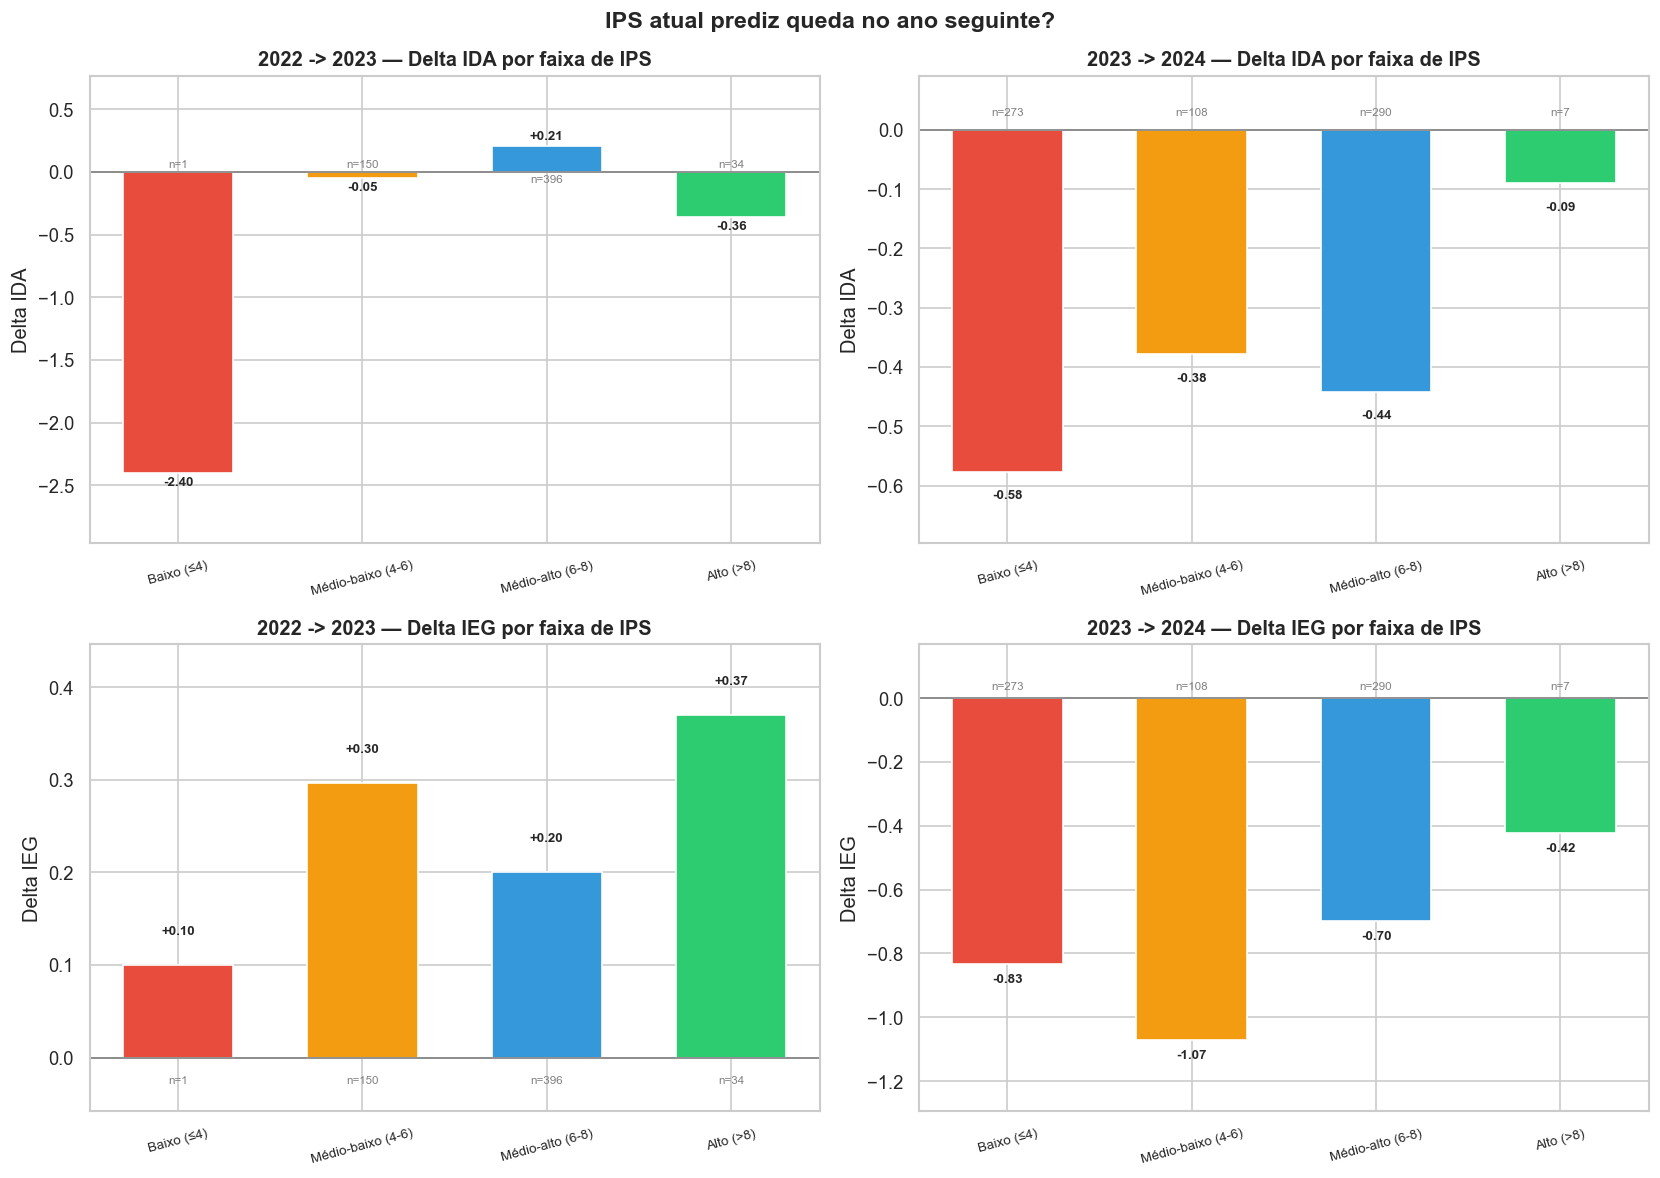

In [7]:
# Visualizar delta IDA e IEG por faixa de IPS, separado por transição
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

faixas = ['Baixo (≤4)', 'Médio-baixo (4-6)', 'Médio-alto (6-8)', 'Alto (>8)']
cores_faixa = {'Baixo (≤4)': '#e74c3c', 'Médio-baixo (4-6)': '#f39c12', 
               'Médio-alto (6-8)': '#3498db', 'Alto (>8)': '#2ecc71'}

for col, transicao in enumerate(['2022 -> 2023', '2023 -> 2024']):
    sub = df_pares[df_pares['ano_atual'] == (2022 if col == 0 else 2023)]
    
    for row, (indicador, delta_col) in enumerate([('IDA', 'delta_IDA'), ('IEG', 'delta_IEG')]):
        ax = axes[row][col]
        
        resumo = sub.groupby('faixa_IPS')[delta_col].agg(['mean', 'count'])
        resumo = resumo.reindex(faixas).dropna()
        
        bars = ax.bar(range(len(resumo)), resumo['mean'], 
                      color=[cores_faixa[f] for f in resumo.index],
                      width=0.6, edgecolor='white')
        
        ax.axhline(0, color='gray', linestyle='-', linewidth=1)
        ax.set_xticks(range(len(resumo)))
        ax.set_xticklabels(resumo.index, fontsize=8, rotation=15)
        ax.set_ylabel(f'Delta {indicador}')
        ax.set_title(f'{transicao} — Delta {indicador} por faixa de IPS', fontweight='bold')
        
        # Rótulos: valor acima da barra, n abaixo
        for j, (faixa, r) in enumerate(resumo.iterrows()):
            valor = r['mean']
            # Posicionar texto sempre fora da barra
            if valor >= 0:
                ax.text(j, valor + 0.03, f'{valor:+.2f}', ha='center', fontsize=8, fontweight='bold', va='bottom')
                ax.text(j, -0.02, f'n={int(r["count"])}', ha='center', fontsize=7, color='gray', va='top')
            else:
                ax.text(j, valor - 0.03, f'{valor:+.2f}', ha='center', fontsize=8, fontweight='bold', va='top')
                ax.text(j, 0.02, f'n={int(r["count"])}', ha='center', fontsize=7, color='gray', va='bottom')
        
        # Dar margem extra no eixo y
        ymin, ymax = ax.get_ylim()
        margem = (ymax - ymin) * 0.15
        ax.set_ylim(ymin - margem, ymax + margem)

        # Tabela resumo
        resumo_txt = sub.groupby('faixa_IPS')[delta_col].agg(['mean', 'median', 'count']).round(2)
        resumo_txt.columns = ['delta_medio', 'delta_mediano', 'n']
        print(f'\n  Delta {indicador} por faixa de IPS:')
        print(resumo_txt.to_string())

plt.suptitle('IPS atual prediz queda no ano seguinte?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 💡 Insights

**2022 -> 2023:** 
- Faixa "Baixo" com apenas 1 aluno (irrelevante). 
- Nas demais: IDA oscila sem padrão claro (-0.05, +0.21, -0.36) e IEG sobe levemente em todas (+0.10 a +0.37)

**2023 -> 2024:**
- Todos os grupos caíram em IDA e IEG — queda generalizada sem gradiente claro entre as faixas.
- "Médio-baixo" cai mais que "Baixo" no IEG (-1.07 vs -0.83)

Correlações brutas confirmam:
- IPS × Delta de IDA (0.117)
- IPS × Delta IEG (0.192)
- Ambas muito fracas

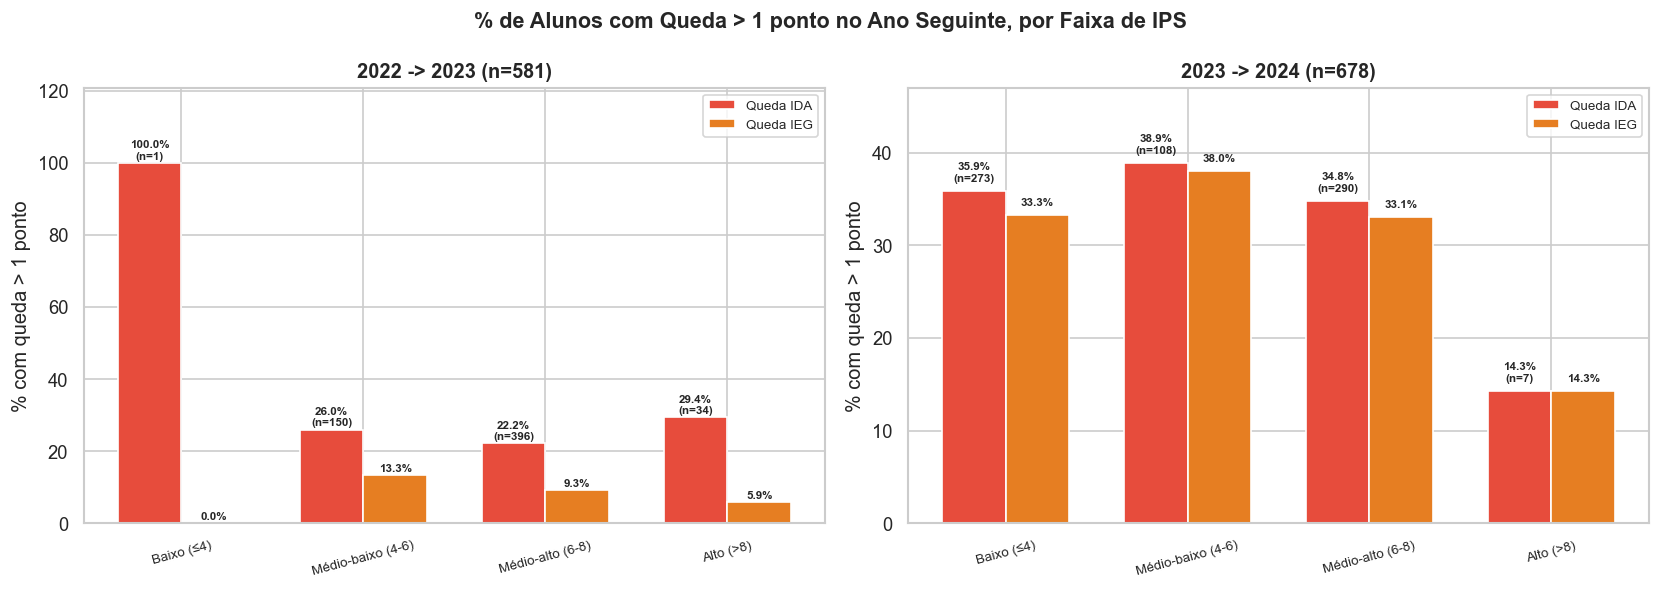

In [8]:
# % de queda por faixa de IPS, separado por transição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

faixas = ['Baixo (≤4)', 'Médio-baixo (4-6)', 'Médio-alto (6-8)', 'Alto (>8)']

for i, transicao in enumerate(['2022 -> 2023', '2023 -> 2024']):
    sub = df_pares[df_pares['ano_atual'] == (2022 if i == 0 else 2023)].copy()
    sub['caiu_IDA'] = sub['delta_IDA'] < -1
    sub['caiu_IEG'] = sub['delta_IEG'] < -1
    
    pct = sub.groupby('faixa_IPS').agg(
        pct_IDA=('caiu_IDA', 'mean'),
        pct_IEG=('caiu_IEG', 'mean'),
        n=('RA', 'count')
    ).reindex(faixas).dropna()
    pct['pct_IDA'] = (pct['pct_IDA'] * 100).round(1)
    pct['pct_IEG'] = (pct['pct_IEG'] * 100).round(1)
    
    x = np.arange(len(pct))
    width = 0.35
    
    bars1 = axes[i].bar(x - width/2, pct['pct_IDA'], width, label='Queda IDA', color='#e74c3c')
    bars2 = axes[i].bar(x + width/2, pct['pct_IEG'], width, label='Queda IEG', color='#e67e22')
    
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(pct.index, fontsize=8, rotation=15)
    axes[i].set_ylabel('% com queda > 1 ponto')
    axes[i].set_title(f'{transicao} (n={len(sub)})', fontweight='bold')
    axes[i].legend(fontsize=8)
    
    for j, (faixa, r) in enumerate(pct.iterrows()):
        axes[i].text(j - width/2, r['pct_IDA'] + 1, f'{r["pct_IDA"]:.1f}%\n(n={int(r["n"])})', 
                     ha='center', fontsize=7, fontweight='bold')
        axes[i].text(j + width/2, r['pct_IEG'] + 1, f'{r["pct_IEG"]:.1f}%', 
                     ha='center', fontsize=7, fontweight='bold')
    
    ymin, ymax = axes[i].get_ylim()
    axes[i].set_ylim(0, ymax * 1.15)

plt.suptitle('% de Alunos com Queda > 1 ponto no Ano Seguinte, por Faixa de IPS', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##### 💡 Insights

**2022 -> 2023:**
- Faixa "Baixo" com n=1 (irrelevante).
- No IDA não há gradiente claro (26.0% → 22.2% → 29.4%).
- No IEG existe gradiente decrescente (13.3% → 9.3% → 5.9%), porém com amostras pequenas nas extremidades

**2023 -> 2024:** 
- Sem gradiente
- IDA oscila entre 34.8% e 38.9% em todas as faixas.
- IEG entre 33.1% e 38.0%.
- A faixa "Médio-baixo" tem a maior taxa de queda (38.9% IDA, 38.0% IEG), não a "Baixo" (35.9% IDA, 33.3% IEG)
  - Exceção: faixa "Alto" com apenas 7 alunos tem a menor queda (14.3%)

O IPS absoluto não diferencia de forma consistente quem vai cair de quem não vai

### ⭐️ Insight Final

#### Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?
**Não foi possível confirmar com os dados disponíveis.**

**Problemas de confiabilidade:**
- Dados estranhos em 2023: média caiu de 6.91 (2022) para 5.12, com 28% dos alunos no valor mínimo da escala (2.52)
- Variação extrema entre turmas em 2023:
  - Diferença de 5.37 pontos, com 4 turmas onde todos receberam a mesma nota (3 com o piso de 2.52 e 1 com com a segunda maior média: 7.52)
- 88.3% das turmas subiram de 2023 para 2024 (delta médio +1.62)
  - indicando recalibração da escala / mudança na forma de avaliação
  - não parece ser uma melhora real
- Alunos com IPS no piso em 2023 tinham indicadores normais nos outros anos (IPS=6.34 em 2022, IPS=6.76 em 2024)

**Não foi possível associar IPS com IEG**
- Sem padrão consistente
- 2022 -> 2023: sem gradiente claro no IDA; gradiente fraco no IEG mas com amostras insuficientes nas extremidades
- 2023 -> 2024: queda generalizada em todas as faixas (~35% IDA, ~33% IEG), sem diferenciação por nível de IPS
- Correlações muito fracas: IPS × Delta IDA (0.117) | IPS × Delta IEG (0.192)

**Causas identificadas:**
- Escala comprimida em 2022 (12 valores únicos) — pouca variação para detectar padrões
- Pisos artificiais em 2023 (265 alunos com 2.52) — faixa "Baixo" não representa risco real
- Aparentemente uma mudança na metodologia entre anos — valores absolutos não são comparáveis

**⚠️ Para o modelo de ML:**
- O IPS como valor absoluto entre anos não é confiável como feature temporal
- Alternativas para o feature engineering: normalização por percentil dentro do ano, z-score dentro da turma, ou feature binária `ips_no_piso`
- O IPS pode ainda ser útil como feature **dentro do mesmo ano** (posição relativa), mas não como preditor temporal entre anos

### Exportação da base analítica para o Streamlit


In [9]:
# EXPORTAR BASE ANALITICA DO IPS PARA O STREAMLIT
from pathlib import Path
import sys

# Usa o caminho conhecido do app a partir dos notebooks de AED.
caminho_app = Path('../../app').resolve()
if str(caminho_app) not in sys.path:
    sys.path.append(str(caminho_app))

from analise_exploratoria.analiticos.ips import exportar_base_analitica_ips

# Gera o parquet analitico que a aba IPS do Streamlit passa a consumir.
caminho_saida = exportar_base_analitica_ips(df)
print(f'Base analitica do IPS exportada para: {caminho_saida}')


2026-03-22 14:14:48.292 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.293 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.294 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.294 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.295 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.295 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.295 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-22 14:14:48.296 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-03-

Base analitica do IPS exportada para: /Users/hgirardi/Documents/Dev/pessoal/Pos_Tech_DTAT/Fase_5/Datathon/data/db/02_gold_analytics/ips_analitico.parquet


In [10]:
# Le o artefato gerado para validar rapidamente a exportacao no proprio notebook.
ips_parquet = pd.read_parquet(caminho_saida)


In [11]:
# Exibe as colunas finais para conferir o contrato usado pela aba do Streamlit.
ips_parquet.columns


Index(['ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso', 'instituicao',
       'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem', 'pedra', 'INDE',
       'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'mat', 'por', 'ing',
       'indicado_bolsa', 'atingiu_pv', 'rec_psicologia', 'pedra_20',
       'pedra_21', 'pedra_22', 'pedra_23', 'faixa_IPS', 'ano_proximo',
       'transicao', 'IPS_proximo', 'IDA_proximo', 'IEG_proximo', 'delta_IDA',
       'delta_IEG', 'caiu_IDA', 'caiu_IEG'],
      dtype='object')